<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/hoang/EDA_Ruou_Do.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân loại chất lượng rượu đỏ

##**1.Định nghĩa vấn đề**

## **2.Chuẩn bị vấn đề**

### **2.1.Khai báo thư viện**

In [ ]:
import pandas as pd  #for data manipulation operations
import numpy as np  #for numeric operations on data
import seaborn as sns  #for data visualization operations
import matplotlib.pyplot as plt  #for data visualization operations
from sklearn.preprocessing import LabelEncoder # for encoding
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler #for standardization
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import scipy.stats as st
from termcolor import colored
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
#!pip install lightgbm
from lightgbm import LGBMClassifier
#ignore warnings
import warnings
warnings.filterwarnings("ignore")
#see model parametres
from sklearn import set_config
set_config(print_changed_only = False)

print(colored("\n THE REQUIRED LIBRARIES WERE SUCCESFULLY IMPORTED...", "green"))


 THE REQUIRED LIBRARIES WERE SUCCESFULLY IMPORTED...


### **2.2.Nạp dữ liệu**

In [1]:
#load data
redwine = pd.read_csv('winequality-red.csv', delimiter=';')

NameError: name 'pd' is not defined

## **3.Mô tả thống kê**

#### **3.1. Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [ ]:
# Get shape
print(f'+ Shape: {redwine.shape}')

# Get types
print(f'\n+ Data Types:\n{redwine.dtypes}')

# Check the first 5 rows (head)
print('\n+ First 5 rows:')
display(redwine.head(5))

# Check the last 5 rows (tail)
print('\n+ Last 5 rows:')
display(redwine.tail(5))

# info
print('\n + Basic Information: ')
redwine.info()

**Thông tin cơ bản của bộ dữ liêu**

Bộ dữ liệu không có giá trị null(thiếu dữ liệu). Bộ dữ liệu gồm 1599 hàng và 12 cột. Kiểu dữ liệu của tất cả các biến đều là dạng số (numeric).

#### **3.2. Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [ ]:
redwine.describe()

**Dựa vào biểu đồ box plot và bảng thống kê mô tả của bộ dữ liệu ta thấy**

*   Giá trị trung bình của fixed acidity là 8.31, giá trị cao nhất là 15.9, giá trị thấp nhất là 4.6
*   Giá trị trung bình của volatile acidity là 0.52, giá trị cao nhất là 1.58, giá trị thấp nhất là 0.12
*   Giá trị trung bình của citric acid là 0.27, giá trị cao nhất là 1.0, giá trị thấp nhất là 0
*   Giá trị trung bình của residual sugar là 2.53, giá trị cao nhất là 15.5, giá trị thấp nhất là 0.9
*   Giá trị trung bình của chlorides là 0.08, giá trị cao nhất là 0.61, giá trị thấp nhất là 0.01
*   Giá trị trung bình của free sulfur dioxide là 15.87, giá trị cao nhất là 72, giá trị thấp nhất là 1
*   Giá trị trung bình của total sulfur dioxide là 46.46, giá trị cao nhất là 289, giá trị thấp nhất là 6
*   Giá trị trung bình của density là 0.996, giá trị cao nhất là 1, giá trị thấp nhất là 0.990
*   Giá trị trung bình của pH	 là 3.31, giá trị cao nhất là 4.01, giá trị thấp nhất là 2.74
*   Giá trị trung bình của sulphates là 0.65, giá trị cao nhất là 2, giá trị thấp nhất là 0.33
*   Giá trị trung bình của alcohol là 10.4, giá trị cao nhất là 14.9, giá trị thấp nhất là 8.4
*   Giá trị trung bình của quality là 5.63, giá trị cao nhất là 8, giá trị thấp nhất là 3

#### **3.3. Kiểm tra tính toàn vẹn của dữ liệu**

Kiểm tra dữ liệu bị trùng lặp

In [ ]:
print("Số dữ liệu bị trùng lập: {} ".format(redwine.isnull().sum().sum()))

## **4.EDA và trực quan hóa dữ liệu**

### **4.1.Phân tích đơn biến (Univariable Analysis)**

+ **Câu hỏi 1:** Chất lượng rượu trong tập dữ liệu được phân bổ như thế nào? Tỷ lệ giữa rượu có chất lượng cao, trung bình và thấp là bao nhiêu?

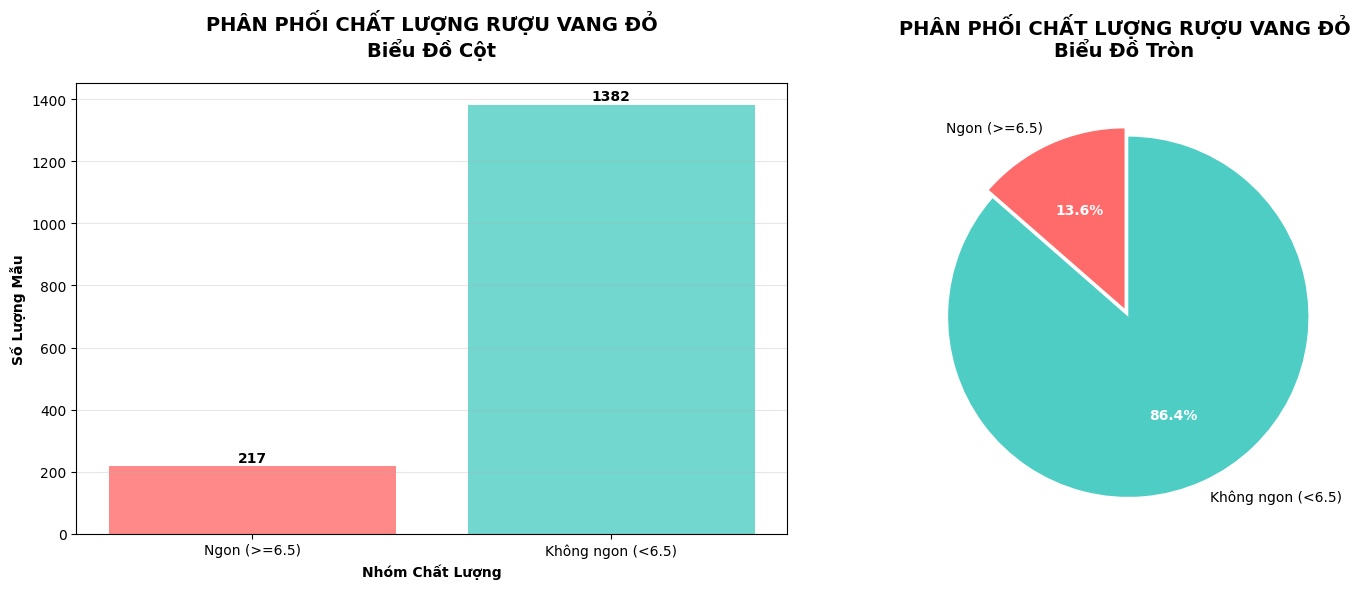

In [ ]:
# 1. Phân loại chất lượng rượu
def classify_quality(score):
    if score >= 6.5:
        return 'Ngon (>=6.5)'
    else:
        return 'Không ngon (<6.5)'

redwine['quality_category'] = redwine['quality'].apply(classify_quality)
quality_counts = redwine['quality_category'].value_counts()

# Đảm bảo thứ tự các nhóm khi vẽ biểu đồ
category_order = ['Ngon (>=6.5)', 'Không ngon (<6.5)']
quality_counts = quality_counts.reindex(category_order)

# 2. Tạo hình vẽ với 2 subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- BAR CHART ---
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
bars = ax1.bar(quality_counts.index, quality_counts.values, color=colors, alpha=0.8)
ax1.set_title('PHÂN PHỐI CHẤT LƯỢNG RƯỢU VANG ĐỎ\nBiểu Đồ Cột', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Nhóm Chất Lượng', fontweight='bold')
ax1.set_ylabel('Số Lượng Mẫu', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Thêm số liệu lên trên mỗi cột
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

# --- PIE CHART ---
wedges, texts, autotexts = ax2.pie(quality_counts.values,
                                   labels=quality_counts.index,
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90,
                                   explode=(0, 0.05))  # Tách nhãn Poor và Good ra một chút

ax2.set_title('PHÂN PHỐI CHẤT LƯỢNG RƯỢU VANG ĐỎ\nBiểu Đồ Tròn', fontsize=14, fontweight='bold', pad=20)

# Làm đẹp cho phần trăm trong pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.tight_layout()
plt.show()

 **Nhận xét:** Chất lượng rượu phân bổ không đồng đều, với đa số (86.4%) ở mức không ngon, tỷ lệ rượu ngon là 13.6%. Điều này phản ánh thực tế là phần lớn rượu vang đỏ trên thị trường có chất lượng kém không ngon, trong khi rượu chất lượng cao thực sự khá hiếm và rất ít.

---

+ **Câu hỏi 2:** Dựa trên tiêu chí nào để xác định yếu tố ảnh hưởng đến chất lượng của rượu?

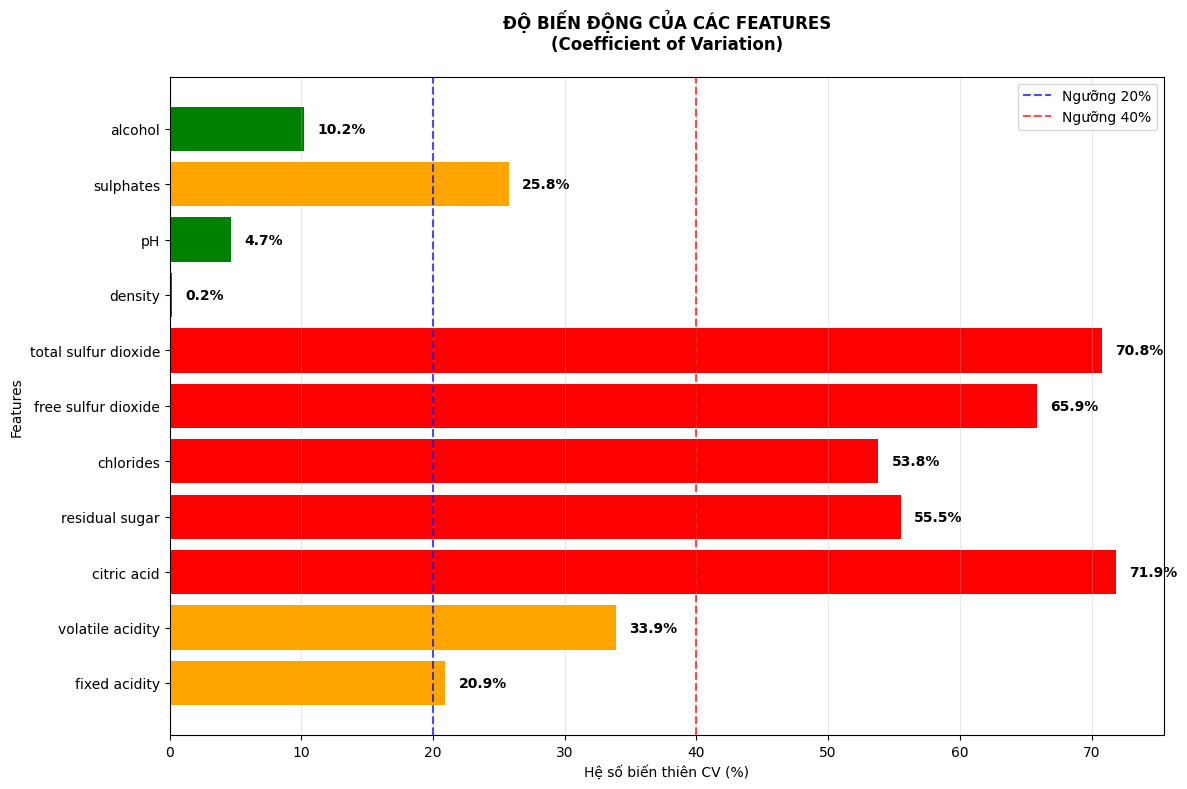

In [ ]:
# Tính hệ số biến thiên (Coefficient of Variation)
cv_analysis = []
for column in redwine.select_dtypes(include=[np.number]).columns:
    if column != 'quality':
        mean_val = redwine[column].mean()
        std_val = redwine[column].std()
        cv = (std_val / mean_val) * 100  # Coefficient of Variation %

        cv_analysis.append({
            'feature': column,
            'mean': mean_val,
            'std': std_val,
            'cv': cv
        })

# Chuyển thành DataFrame và sắp xếp
cv_df = pd.DataFrame(cv_analysis).sort_values('cv', ascending=False)

# BIỂU ĐỒ ĐỘ BIẾN ĐỘNG
plt.figure(figsize=(12, 8))
bars = plt.barh([x['feature'] for x in cv_analysis], [x['cv'] for x in cv_analysis],
                color=['red' if x['cv'] > 40 else 'orange' if x['cv'] > 20 else 'green' for x in cv_analysis])

# Thêm giá trị CV trên các cột
for bar, value in zip(bars, [x['cv'] for x in cv_analysis]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{value:.1f}%', va='center', fontweight='bold')

plt.axvline(x=20, color='blue', linestyle='--', alpha=0.7, label='Ngưỡng 20%')
plt.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='Ngưỡng 40%')
plt.xlabel('Hệ số biến thiên CV (%)')
plt.ylabel('Features')
plt.title('ĐỘ BIẾN ĐỘNG CỦA CÁC FEATURES\n(Coefficient of Variation)', fontweight='bold', pad=20)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

high_variability = cv_df[cv_df['cv'] > 40]
medium_variability = cv_df[(cv_df['cv'] > 20) & (cv_df['cv'] <= 40)]
low_variability = cv_df[cv_df['cv'] <= 20]

# CHỌN FEATURES QUAN TRỌNG DỰA TRÊN BIẾN ĐỘNG
selected_features = cv_df[cv_df['cv'] > 15]['feature'].tolist()

**Nhận xét:** Qua quá trình phân tích hệ số biến thiên (CV), việc xác định các yếu tố ảnh hưởng đến chất lượng rượu dựa theo tiêu chí ĐỘ BIẾN ĐỘNG. Các features có CV cao (>40%) cho thấy sự ĐA DẠNG lớn giữa các mẫu rượu, do đó đáng để phân tích sâu. Ngược lại, features có CV thấp (40%) cho thấy sự ĐỒNG NHẤT, ít mang lại thông tin có giá trị.

---

+ **Câu hỏi 3:** Phân bố thực tế của các yếu tố có biến động cao (CV > 40%) như thế nào, và có xuất hiện các giá trị ngoại lai (outliers) đáng chú ý không?

Dựa trên đồ biểu đồ phân tích hệ số biến thiên trên, ta chọn được 5 features có CV cao (>40%) để tiếp tục tìm hiểu sự phân bố của chúng:
  + total sulfur dioxide (70.8%)
  + free sulfur dioxide (65.9%)
  + chlorides (53.8%)
  + residual sugar (55.5%)
  + citric acid (71.9%)

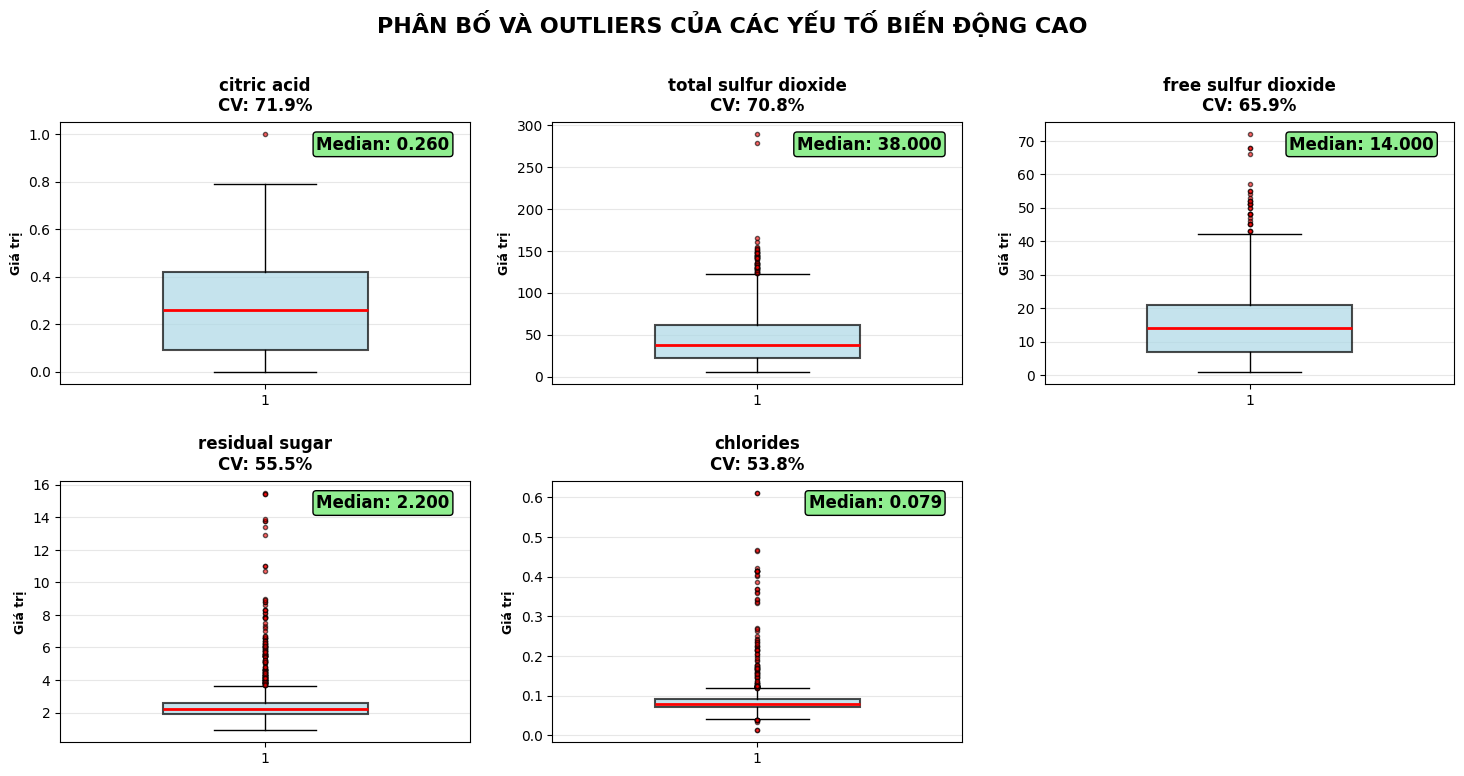

In [ ]:
# Chọn top 5 features có CV cao nhất
high_cv_features = ['citric acid', 'total sulfur dioxide', 'free sulfur dioxide',
                    'residual sugar', 'chlorides']

# Tạo subplots với kích thước vừa phải
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(high_cv_features):
    # Box plot cho từng feature riêng
    boxprops = dict(facecolor='lightblue', alpha=0.7, linewidth=1.5)
    medianprops = dict(color='red', linewidth=2)
    flierprops = dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.6)

    # Vẽ box plot
    axes[i].boxplot(redwine[feature],
                   boxprops=boxprops,
                   medianprops=medianprops,
                   flierprops=flierprops,
                   patch_artist=True,
                   widths=0.5)

    cv_value = cv_df[cv_df['feature'] == feature]['cv'].values[0]

    # Đặt title với font size vừa phải
    axes[i].set_title(f'{feature}\nCV: {cv_value:.1f}%', fontweight='bold', fontsize=12, pad=8)
    axes[i].set_ylabel('Giá trị', fontweight='bold', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

    # Thêm thống kê median - GÓC PHẢI TRÊN CÙNG
    median = redwine[feature].median()
    axes[i].text(0.95, 0.95, f'Median: {median:.3f}',
                transform=axes[i].transAxes,
                ha='right', va='top', fontweight='bold', fontsize=12,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen"))

# Ẩn subplot thừa
for i in range(len(high_cv_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('PHÂN BỐ VÀ OUTLIERS CỦA CÁC YẾU TỐ BIẾN ĐỘNG CAO',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(pad=2.0)
plt.show()

**Nhận xét:**
  + Citric Acid: Phân bố hơi lệch phải, đa số rượu có hàm lượng acid citric thấp (median = 0.260), có 1 outlier ở phía trên
  + Total Sulfur Dioxide: Phân bố lệch phải, nhiều outliers ở phía trên, một số giá trị cực đại lên đến gần 300, cho thấy có một số rượu chứa hàm lượng SO₂ rất cao.
  + Free Sulfur Dioxide: Phân bố lệch phải, có nhiều outliers, giá trị lớn nhất khoảng trên 70, phần lớn rượu có hàm lượng SO₂ tự do thấp (median = 14).
  + Residual Sugar: Phân bố lệch phải rõ rệt, đa số rượu có hàm lượng đường dư thấp (median = 2.200), nhưng xuất hiện nhiều outliers vượt xa khỏi mức bình thường, có thể do một số rượu ngọt đặc biệt.
  + Chlorides: Phân bố lệch phải, có outliers ở cả hai phía, nhưng tập trung nhiều hơn ở phía giá trị cao. Hàm lượng muối trung bình thấp (median = 0.079).

  → Các features có biến động cao đều có xu hướng lệch phải và xuất hiện nhiều outliers, chủ yếu ở phía giá trị cao

---

+ **Câu hỏi 4:** Vậy outliers phân bố không đều giữa các features như thế nào? Features nào NHIỀU outliers nhất? Features nào ÍT outliers nhất?
      



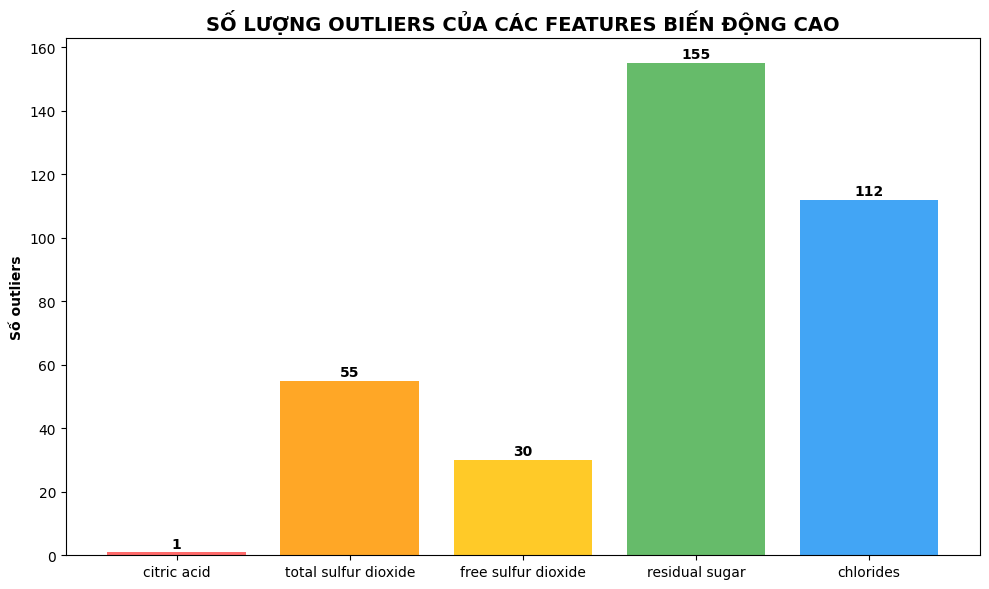

In [ ]:
# BIỂU ĐỒ ĐƠN GIẢN - CHỈ OUTLIERS COUNT
plt.figure(figsize=(10, 6))
outlier_data = []
for feature in high_cv_features:
    Q1 = redwine[feature].quantile(0.25)
    Q3 = redwine[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = redwine[(redwine[feature] < Q1 - 1.5 * IQR) | (redwine[feature] > Q3 + 1.5 * IQR)]
    outlier_data.append(len(outliers))

bars = plt.bar(high_cv_features, outlier_data,
               color=['#ff6b6b', '#ffa726', '#ffca28', '#66bb6a', '#42a5f5'])
plt.title('SỐ LƯỢNG OUTLIERS CỦA CÁC FEATURES BIẾN ĐỘNG CAO', fontsize=14, fontweight='bold')
plt.ylabel('Số outliers', fontweight='bold')

# Thêm số trên các cột
for bar, count in zip(bars, outlier_data):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** Residual Sugar và Chlorides là hai features có số outliers cao nhất, cho thấy sự xuất hiện của những mẫu rượu có đặc tính cực kỳ khác biệt về độ ngọt và vị mặn so với đa số còn lại. Trong khi đó, Citric Acid có số outliers thấp nhất trong nhóm, dù có CV cao nhất.

→ Điều này cho thấy CV cao không nhất thiết đồng nghĩa với nhiều outliers. Citric Acid có độ biến động cao nhưng phân bố tương đối đồng đều, trong khi Residual Sugar và Chlorides có cả độ biến động cao và tập trung nhiều giá trị cực đoan.

---

### **4.2.Phân tích đa biến (Multivariable Analysis)**

+ **Câu hỏi 1:** Các thuộc tính ảnh hưởng như thế nào đến điểm chất lượng (quality) của rượu?
  + Thuộc tính nào GIÚP NÂNG chất lượng?
  + Thuộc tính nào LÀM GIẢM chất lượng?
  + Thuộc tính nào KHÔNG ẢNH HƯỞNG đến chất lượng?

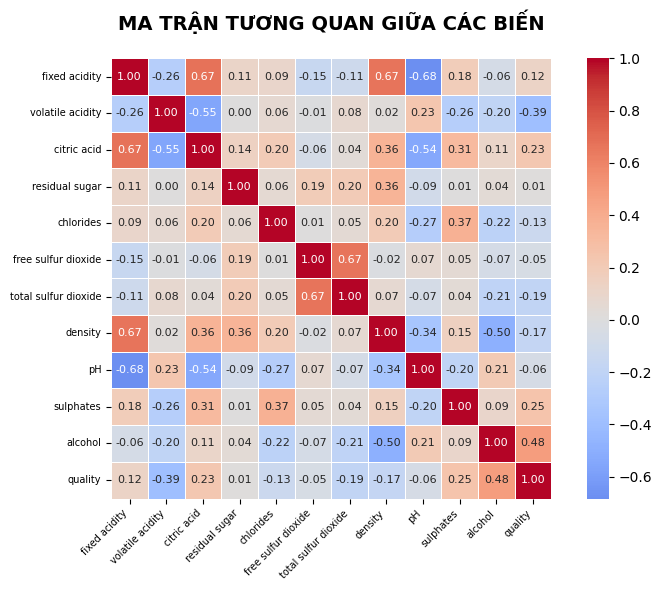

In [ ]:
# PHÂN TÍCH ĐA BIẾN - Câu hỏi 1
# Biến hóa học nào có ảnh hưởng LỚN NHẤT và NHỎ NHẤT đến điểm chất lượng (quality) của rượu?

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính ma trận tương quan
correlation_matrix = redwine.corr(numeric_only=True)

# 2. Tạo heatmap TOÀN BỘ ma trận (bỏ mask)
plt.figure(figsize=(8, 6))  # Thu nhỏ kích thước tổng thể

sns.heatmap(correlation_matrix,
            annot=True,         # Hiển thị số trên ô
            fmt=".2f",          # Định dạng số: 2 chữ số thập phân
            cmap='coolwarm',    # Bản đồ màu: xanh (âm) - trắng - đỏ (dương)
            center=0,           # Tâm của màu ở giá trị 0
            square=True,
            linewidths=0.5,
            annot_kws={"size": 8})  # Thu nhỏ cỡ chữ trong ô để dễ đọc

plt.title('MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=7)  # Thu nhỏ cỡ chữ trục X
plt.yticks(rotation=0, fontsize=7)               # Thu nhỏ cỡ chữ trục Y
plt.tight_layout()
plt.show()


**Nhận xét các thuộc tính có mối quan hệ với chất lượng (quanlity):**
  + Alcohol(Nồng độ cồn) có mối tương quan mạnh với quality (+0.48), cho thấy hàm lượng cồn ảnh hưởng khá lớn đến chất lượng của rượu. Rượu có hàm lượng cồn cao thường có chất lượng tốt hơn.
  + Volatile acidity(độ axit dễ bay hơi) có tương quan âm khá cao với quality (-0.39), cho thấy nếu volatile acidity tăng, có thể làm giảm chất lượng của rượu, vì sự biến đổi nhanh chóng của axit dễ làm rượu bị chua, có mùi giấm.
  + Residual sugar(lượng đường dư) gần như không có mối quan hệ nào với quanlity (0.01), dù rằng một chút đường dư có thể cải thiện cảm giác ngọt ngào trong rượu. Tuy nhiên, mối tương quan gần như không có, cho thấy rằng mức độ đường dư không phải yếu tố quyết định trong việc đánh giá chất lượng của rượu.

**Ngoài ra,nhận thấy các thuộc tính có độ tương quan cao sau:**
  + Fixed acidity, citric acid và pH(> 0.54)
  + Total sulfur dioxide và free sulfur dioxide(+0.67)
  + Density và alcohol (-0.50), density và fixed acidity (+0.67)
  + citric acid và volatile acidity (-0.55)


---

**-> Phân tích mức độ tương quan của nhóm Axit (fixed acidity, citric acid và pH)**
  + fixed acidity và quanlity (+0.12)
  + citric acid và quanlity (+0.23)
  + pH và quanlity (-0.06)

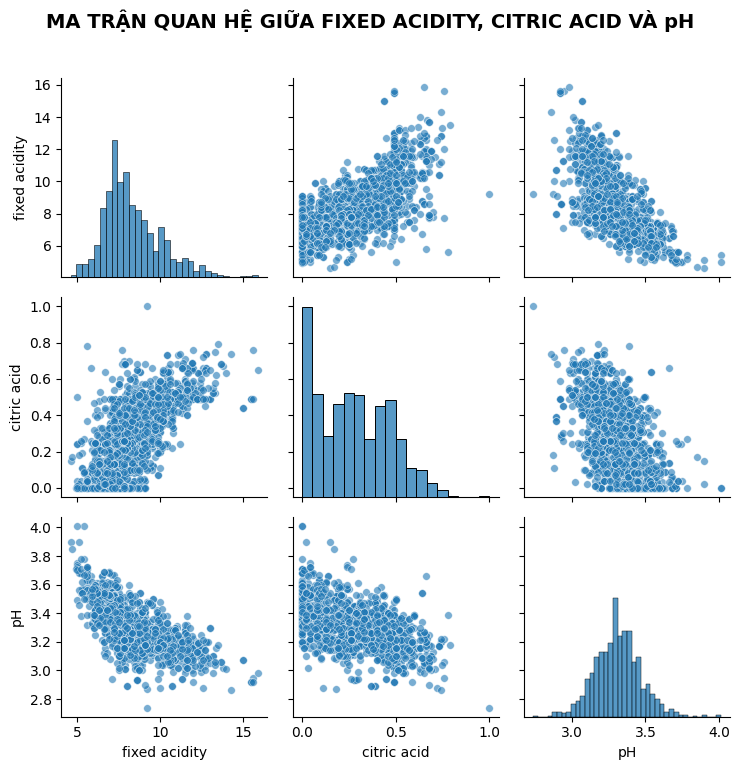

In [ ]:
# Tạo pair plot cho 3 biến
sns.pairplot(redwine[['fixed acidity', 'citric acid', 'pH']],
             diag_kind='hist',  # Dùng histogram trên đường chéo
             plot_kws={'alpha': 0.6, 's': 30})  # Điều chỉnh độ trong suốt và kích thước điểm

plt.suptitle('MA TRẬN QUAN HỆ GIỮA FIXED ACIDITY, CITRIC ACID VÀ pH',
             y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét chung:** Biểu đồ cho thấy một vòng tròn logic: Fixed Acidity và Citric Acid cùng tăng giảm với nhau (dương tính). Cả hai cùng 'kéo' giá trị pH đi xuống (âm tính). Điều này khẳng định chúng là một nhóm gắn bó chặt chẽ, cùng mô tả đặc tính về độ chua của rượu."

**Điểm khác biệt:** citric acid có tương quan dương nhẹ (+0.23) với chất lượng, trong khi fixed acidity gần như không có tương quan (+0.12). Vì thế mà đối với chất lượng, *loại axit* quan trọng hơn *tổng lượng axit*. Một chai rượu tốt không cần phải có độ axit cố định (fixed acidity) thật cao, mà cần có sự cân bằng phù hợp, trong đó axit citric (citric acid) là axit "tốt" mang lại vị tươi sáng - đóng vai trò then chốt.


---

**-> Phân tích mối quan hệ giữa Mật độ (Density) với các thành phần chính của rượu**
  + Density và quanlity (-0.17)
  + Alcohol và quanlity (0.48)
  + Fixed acidity và quanlity (-0.12)

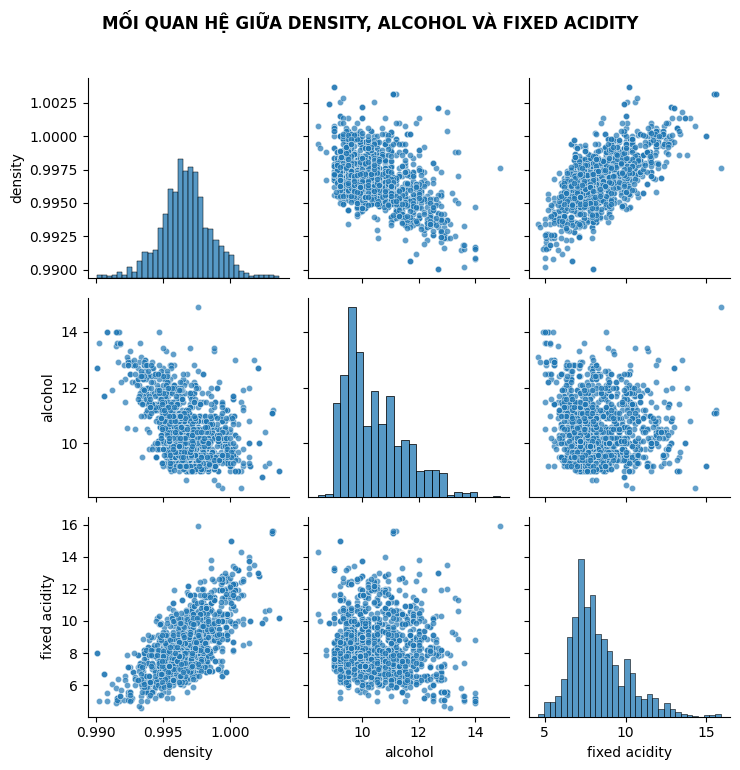

In [ ]:
# Tạo pairplot với kích thước nhỏ hơn và tối ưu cho việc quan sát
sns.pairplot(redwine[['density', 'alcohol', 'fixed acidity']],
             diag_kind='hist',
             plot_kws={'alpha': 0.7, 's': 20},
             height=2.5,
             aspect=1)

plt.suptitle('MỐI QUAN HỆ GIỮA DENSITY, ALCOHOL VÀ FIXED ACIDITY',
             y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét chung:** Biểu đồ cho thấy mật độ (density) của rượu bị kéo giữa hai thứ: cồn (alcohol) và axit (fixed acidity). Cồn càng nhiều thì rượu càng nhẹ (density giảm), ngược lại, axit càng nhiều thì rượu càng nặng (density tăng). Density không phải là thứ quyết định chất lượng, mà nó là kết quả của việc cồn và axit trong chai rượu đó nhiều hay ít.

**Điểm khác biệt:** Mặc dù cùng ảnh hưởng đến density, nhưng chỉ có cồn (alcohol) mới thực sự làm rượu ngon hơn. Axit (fixed acidity) gần như không giúp cải thiện chất lượng. Vì vậy, một chai rượu có density thấp thường là một chai rượu ngon. Lý do rất đơn giản: density thấp đồng nghĩa với việc cồn trong chai đó cao - và cồn cao chính là dấu hiệu quan trọng nhất của rượu chất lượng.

---

**-> Phân tích mức độ tương quan của nhóm Lưu huỳnh đioxit (Sulfur Dioxide)**
  + total sulfur dioxide và quanlity (-0.19)
  + free sulfur dioxide và quanlity (-0.05)

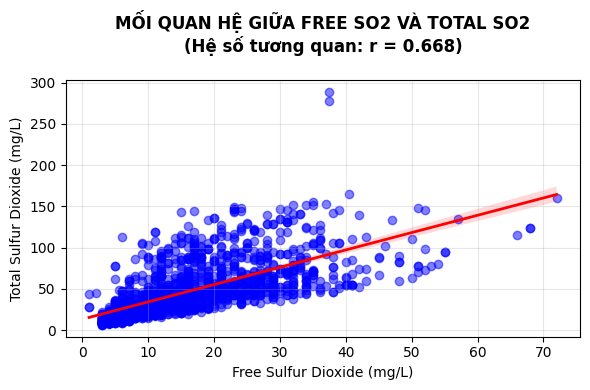

In [ ]:
# Vẽ scatter plot chi tiết hơn
plt.figure(figsize=(6, 4))
sns.regplot(data=redwine,
            x='free sulfur dioxide',
            y='total sulfur dioxide',
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red', 'linewidth':2})

plt.xlabel('Free Sulfur Dioxide (mg/L)')
plt.ylabel('Total Sulfur Dioxide (mg/L)')

title = f'MỐI QUAN HỆ GIỮA FREE SO2 VÀ TOTAL SO2\n(Hệ số tương quan: r = {redwine["total sulfur dioxide"].corr(redwine["free sulfur dioxide"]):.3f})'
plt.title(title, fontweight='bold', pad=20)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét chung:** Biểu đồ cho thấy đồng biến dương rất mạnh và rõ rệt giữa free sulfur dioxide và total sulfur dioxide. Điều này là hoàn toàn hợp lý về mặt hóa học vì free SO₂ là một phần cấu thành của total SO₂. Khi tổng lượng SO₂ thay đổi, lượng SO₂ tự do cũng sẽ thay đổi theo một cách có thể dự đoán được.

**Điểm khác biệt:** total sulfur dioxide và quanlity (-0.19), nên total SO₂ có tác động tiêu cực nhẹ . Điều này có thể là do ở hàm lượng rất cao, SO₂ có thể tạo ra mùi khó chịu.

---

**-> Phân tích mức độ tương quan giữa hai loại axit trong rượu**
  + citric acid và quanlity (0.23)
  + volatile acidity và quanlity (-0.39)

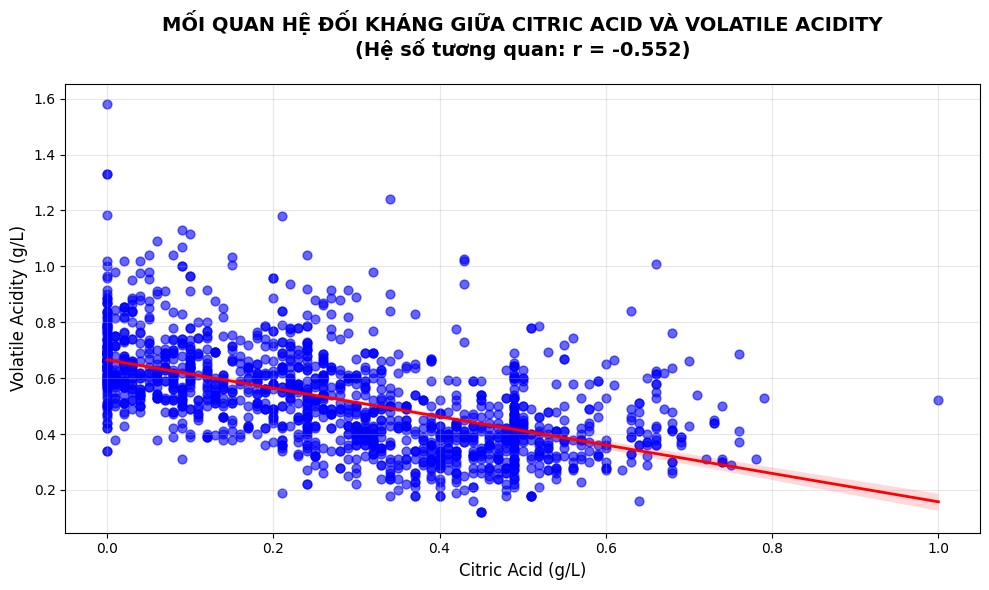

In [ ]:
# Tạo scatter plot
plt.figure(figsize=(10, 6))

# Vẽ scatter plot với đường hồi quy
scatter = sns.regplot(data=redwine,
                      x='citric acid',
                      y='volatile acidity',
                      scatter_kws={'alpha':0.6, 'color':'blue', 's':40},
                      line_kws={'color':'red', 'linewidth':2})

plt.xlabel('Citric Acid (g/L)', fontsize=12)
plt.ylabel('Volatile Acidity (g/L)', fontsize=12)

# Sửa lỗi xuống dòng - gộp thành một chuỗi duy nhất
title_text = f'MỐI QUAN HỆ ĐỐI KHÁNG GIỮA CITRIC ACID VÀ VOLATILE ACIDITY\n(Hệ số tương quan: r = {redwine["citric acid"].corr(redwine["volatile acidity"]):.3f})'
plt.title(title_text, fontsize=14, fontweight='bold', pad=20)

# Thêm lưới để dễ đọc
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Nhận xét chung:** Biểu đồ cho thấy mối quan hệ *"một mất, một còn"* giữa hai loại axit: citric acid (axit citric) và volatile acidity (axit dễ bay hơi). Khi citric acid tăng thì volatile acidity giảm, và ngược lại. Hai loại axit này gần như không bao giờ cùng tồn tại ở mức cao trong một chai rượu.

**Điểm khác biệt:** Mặc dù cả hai đều là axit, nhưng ảnh hưởng của chúng lên chất lượng hoàn toàn trái ngược. Citric acid hỗ trợ tích cực cho chất lượng (+0.23), trong khi volatile acidity là yếu tố tiêu cực chính (-0.39). Do đó, một chai rượu chất lượng cao thường có citric acid cao đi kèm với volatile acidity thấp - sự kết hợp này đảm bảo hương vị tươi sáng và hạn chế các tạp chất gây mùi khó chịu.



---

## **5. Kết luận**

**1. Hồ sơ một chai rượu CHẤT LƯỢNG TỐT**
+ Một chai rượu được đánh giá cao thường sở hữu nhóm đặc tính then chốt sau:
    + Nồng độ cồn (alcohol) cao: Đây là yếu tố dự báo tích cực mạnh mẽ và quan trọng nhất.
    + Độ axit dễ bay hơi (volatile acidity) thấp: Đảm bảo rượu không có mùi giấm hoặc mùi khó chịu.
    + Hàm lượng axit citric (citric acid) ở mức trung bình đến cao: Góp phần tạo nên vị tươi sáng, cân bằng và có liên quan đến việc kìm hãm sự phát triển của axit dễ bay hơi.

**2. Dấu hiệu nhận biết một chai rượu CHẤT LƯỢNG KÉM**
+ Ngược lại, một chai rượu kém chất lượng thường mắc phải một hoặc nhiều lỗi sau:
  + Độ axit dễ bay hơi (volatile acidity) quá cao: Đây là "lỗi" phổ biến và nghiêm trọng nhất.
  + Nồng độ cồn (alcohol) thấp: Thiếu đi sự đậm đà và cấu trúc.
  + Hàm lượng muối (chlorides) cao: Có thể khiến rượu có vị mặn hoặc đắng khó chịu. ( ảnh hưởng ít )

**3. Đề xuất Giải pháp cho Nhà sản xuất**
  + Tập trung kiểm soát quy trình lên men: Để hạn chế tối đa sự hình thành axit dễ bay hơi (volatile acidity) - "kẻ phá hoại" số một.
  + Tận dụng mối quan hệ đối kháng: Giữa axit citric và axit dễ bay hơi, bằng cách duy trì một hàm lượng citric acid phù hợp để ổn định chất lượng.
  + Tối ưu hóa để đạt nồng độ cồn (alcohol) phù hợp: Thay vì tập trung vào các chỉ số ít ảnh hưởng như đường dư (residual sugar).

# **Kết thúc**